In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data = pd.read_csv("heart.csv")
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [3]:
data.shape

(918, 12)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [7]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
num_cols = data.select_dtypes(include = ["int64", "float64"]).columns
num_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')

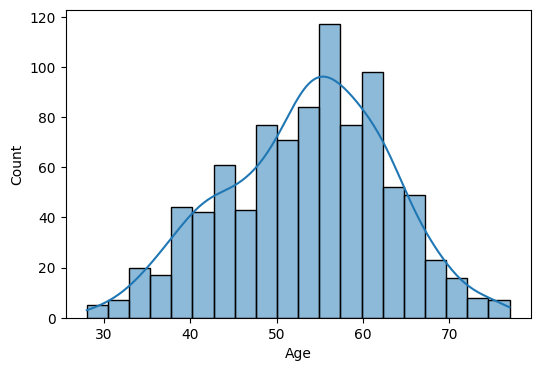

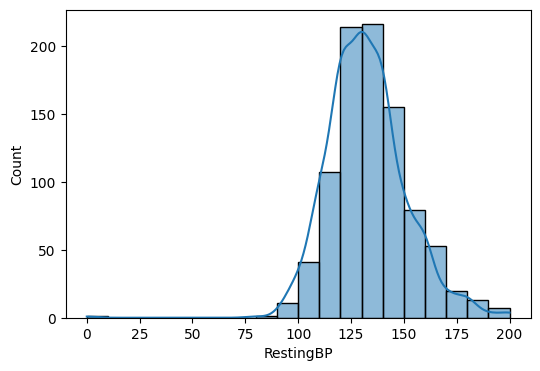

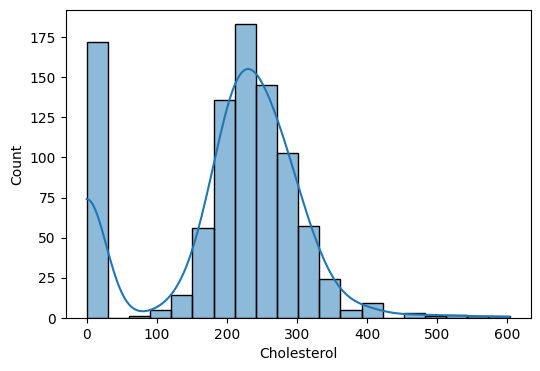

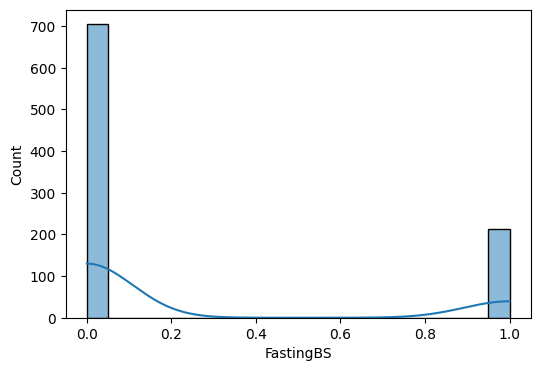

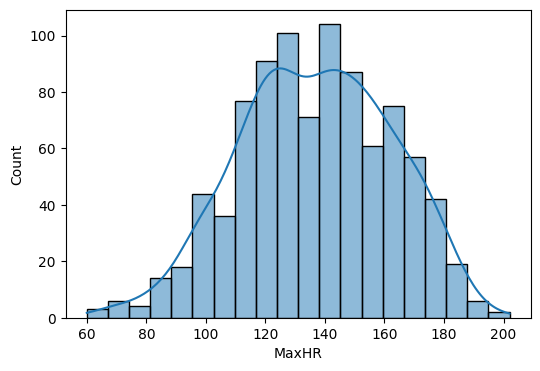

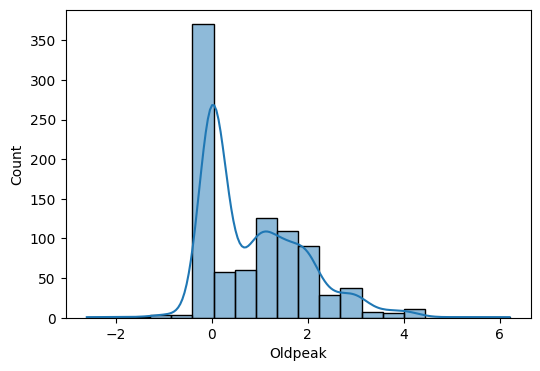

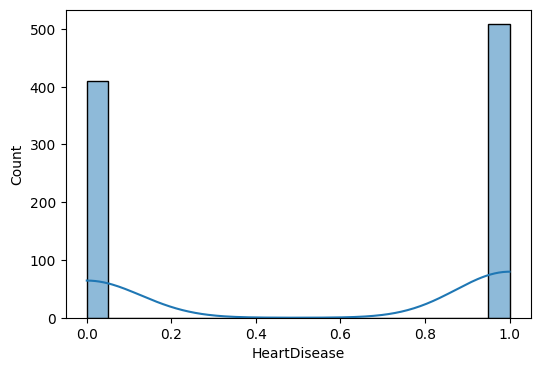

In [9]:
for cols in num_cols:
    plt.figure(figsize = (6, 4))
    sns.histplot(data[cols], kde = True, bins = 20)

<Axes: xlabel='FastingBS', ylabel='count'>

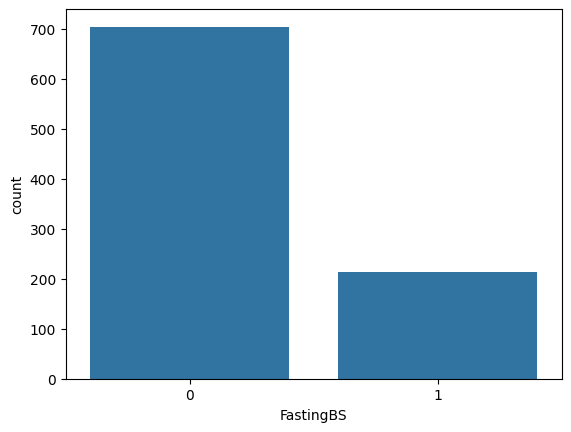

In [10]:
sns.countplot(x = data["FastingBS"])

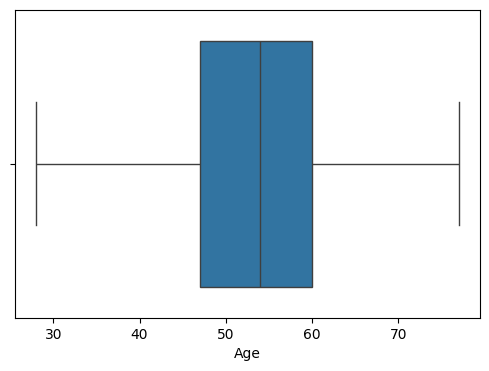

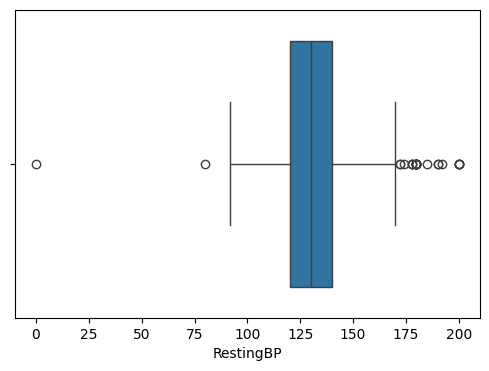

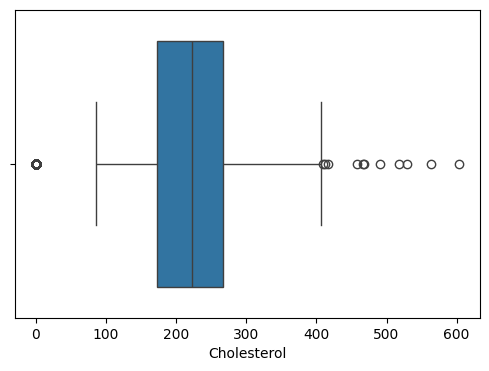

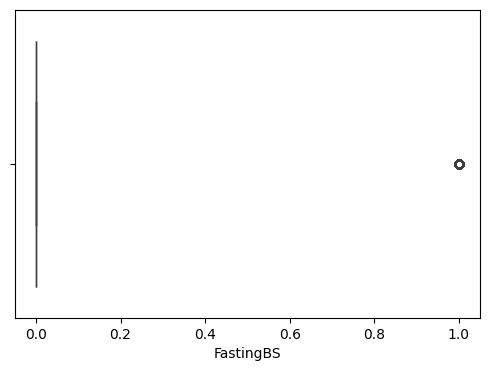

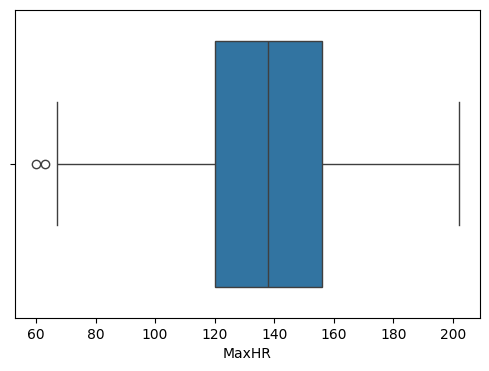

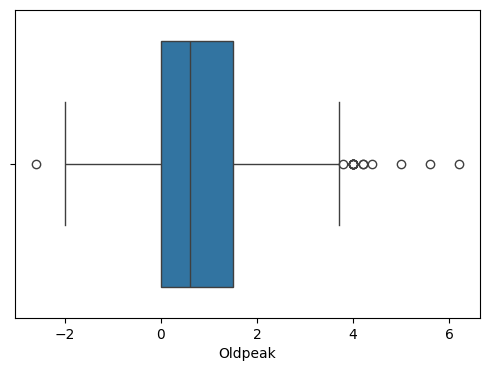

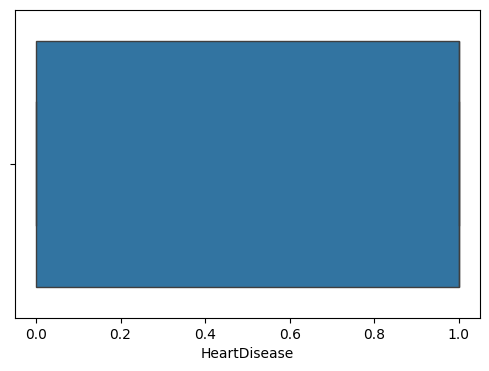

In [12]:
for col in num_cols:
    plt.figure(figsize = (6, 4))
    sns.boxplot(x = data[col])

<Axes: >

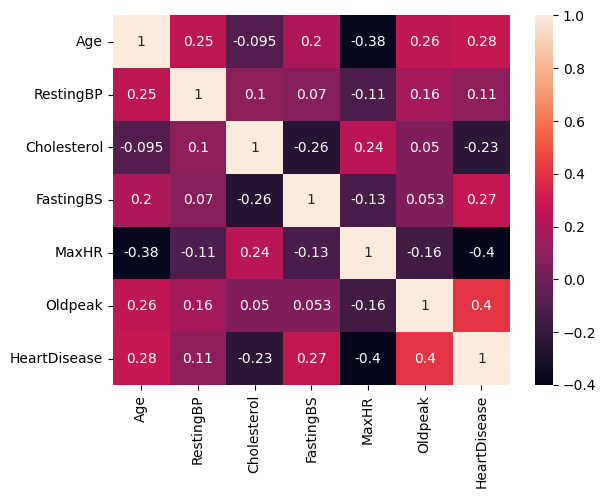

In [13]:
plt.Figure(figsize = (8, 6))
sns.heatmap(data.corr(numeric_only = True), annot = True)

In [14]:
clean = data.copy()

In [15]:
clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [16]:
clean.shape

(918, 12)

In [17]:
clean.drop_duplicates(inplace = True)

In [18]:
clean.shape

(918, 12)

In [19]:
clean.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [21]:
clean.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [23]:
clean["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [24]:
clean["Sex"] = clean["Sex"].map({"M" : 0, "F" : 1})

In [26]:
clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
clean["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [28]:
clean["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [29]:
clean["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [30]:
clean["ExerciseAngina"] = clean["ExerciseAngina"].map({"Y" : 1, "N" : 0})

In [31]:
clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [32]:
clean["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [34]:
clean = pd.get_dummies(clean, columns = ["ChestPainType", "RestingECG", "ST_Slope"], drop_first = True, dtype = int)

In [35]:
clean.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


In [36]:
clean = clean.astype(int)

In [37]:
clean

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0


# Feature Engineering & Extraction

<Axes: xlabel='Age', ylabel='Count'>

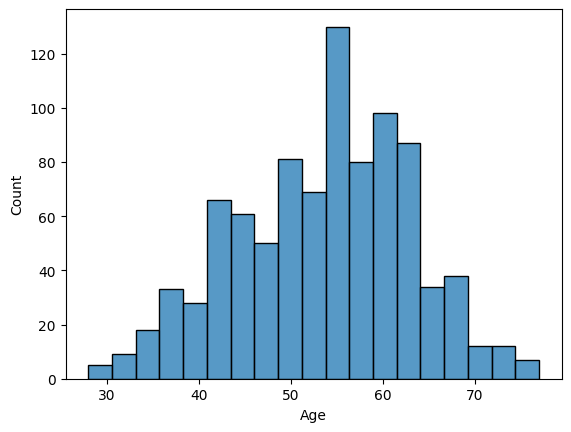

In [39]:
sns.histplot(data["Age"])

In [42]:
clean["Age_Category"] = pd.cut(
    clean["Age"], 
    bins = [20, 45, 65, 80], 
    labels = ["Young", "Middle_Aged", "Elderly"]
)

In [43]:
clean.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Age_Category
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1,Young
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0,Middle_Aged
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1,Young
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0,Middle_Aged
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1,Middle_Aged


In [48]:
clean = pd.get_dummies(clean, columns = ["Age_Category"], drop_first = True, dtype = int)

In [49]:
clean = clean.astype(int)

In [50]:
clean

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Age_Category_Middle_Aged,Age_Category_Elderly
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1,0,0
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1,0,0
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0,0,0
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0,0,1
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0,1,0


# Feature Scaling

In [51]:
clean.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up',
       'Age_Category_Middle_Aged', 'Age_Category_Elderly'],
      dtype='str')

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

In [54]:
scaler = StandardScaler()

clean[cols] = scaler.fit_transform(clean[cols])

In [55]:
clean.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Age_Category_Middle_Aged,Age_Category_Elderly
0,-1.433140,0,0.410909,0.825070,0,1.382928,0,-0.727592,0,1,0,0,1,0,0,1,0,0
1,-0.478484,1,1.491752,-0.171961,0,0.754157,0,0.282891,1,0,1,0,1,0,1,0,1,0
2,-1.751359,0,-0.129513,0.770188,0,-1.525138,0,-0.727592,0,1,0,0,0,1,0,1,0,0
3,-0.584556,1,0.302825,0.139040,0,-1.132156,1,0.282891,1,0,0,0,1,0,1,0,1,0
4,0.051881,0,0.951331,-0.034755,0,-0.581981,0,-0.727592,0,0,1,0,1,0,0,1,1,0


In [57]:
corr = clean.corr(numeric_only = True)

corr["HeartDisease"].sort_values(ascending = False)

HeartDisease                1.000000
ST_Slope_Flat               0.554134
ExerciseAngina              0.494282
Oldpeak                     0.392385
Age                         0.282039
FastingBS                   0.267291
Age_Category_Middle_Aged    0.170907
RestingBP                   0.107589
RestingECG_ST               0.102527
Age_Category_Elderly        0.089296
ChestPainType_TA           -0.054790
RestingECG_Normal          -0.091580
ChestPainType_NAP          -0.212964
Cholesterol                -0.232741
Sex                        -0.305445
MaxHR                      -0.400421
ChestPainType_ATA          -0.401924
ST_Slope_Up                -0.622164
Name: HeartDisease, dtype: float64

In [58]:
clean.corr(numeric_only = True)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Age_Category_Middle_Aged,Age_Category_Elderly
Age,1.000000,-0.055750,0.254399,-0.095282,0.198039,-0.382045,0.215793,0.222111,0.282039,-0.218165,-0.011335,0.032042,-0.230566,0.136798,0.185568,-0.258067,0.344777,0.529548
Sex,-0.055750,1.000000,-0.005133,0.200092,-0.120076,0.189186,-0.190664,-0.107969,-0.305445,0.161522,0.066486,0.004031,0.010634,-0.063715,-0.116077,0.150942,-0.026492,-0.020993
RestingBP,0.254399,-0.005133,1.000000,0.100893,0.070193,-0.112135,0.155101,0.158705,0.107589,-0.046153,-0.041348,0.049855,-0.116851,0.090447,0.099207,-0.096146,0.109317,0.111972
Cholesterol,-0.095282,0.200092,0.100893,1.000000,-0.260974,0.235792,-0.034166,0.043229,-0.232741,0.150954,-0.006634,0.017365,-0.038470,-0.133106,-0.050953,0.094027,-0.048331,-0.028248
FastingBS,0.198039,-0.120076,0.070193,-0.260974,1.000000,-0.131438,0.060451,0.041421,0.267291,-0.140514,-0.039249,0.026885,-0.093028,0.127110,0.107006,-0.161730,0.094233,0.089288
MaxHR,-0.382045,0.189186,-0.112135,0.235792,-0.131438,1.000000,-0.370425,-0.165156,-0.400421,0.253735,0.134580,0.100025,0.023801,-0.157879,-0.342581,0.383397,-0.219873,-0.139192
ExerciseAngina,0.215793,-0.190664,0.155101,-0.034166,0.060451,-0.370425,1.000000,0.396723,0.494282,-0.300365,-0.166030,-0.128105,-0.072924,0.107036,0.382237,-0.455676,0.151460,0.045613
Oldpeak,0.222111,-0.107969,0.158705,0.043229,0.041421,-0.165156,0.396723,1.000000,0.392385,-0.235215,-0.122455,0.009475,-0.095464,0.063570,0.272501,-0.436676,0.115402,0.073160
HeartDisease,0.282039,-0.305445,0.107589,-0.232741,0.267291,-0.400421,0.494282,0.392385,1.000000,-0.401924,-0.212964,-0.054790,-0.091580,0.102527,0.554134,-0.622164,0.170907,0.089296
ChestPainType_ATA,-0.218165,0.161522,-0.046153,0.150954,-0.140514,0.253735,-0.300365,-0.235215,-0.401924,1.000000,-0.256767,-0.110679,0.107941,-0.046111,-0.304667,0.357588,-0.094631,-0.102089


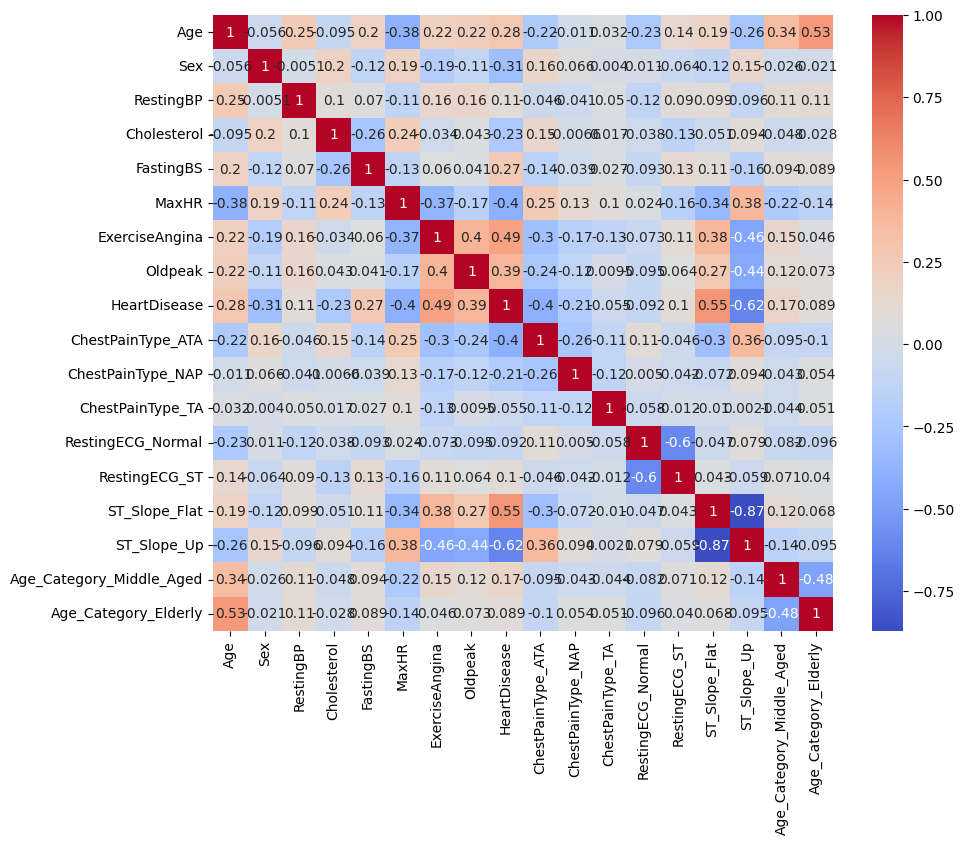

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(clean.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [61]:
clean.nunique()

Age                          50
Sex                           2
RestingBP                    67
Cholesterol                 222
FastingBS                     2
MaxHR                       119
ExerciseAngina                2
Oldpeak                       9
HeartDisease                  2
ChestPainType_ATA             2
ChestPainType_NAP             2
ChestPainType_TA              2
RestingECG_Normal             2
RestingECG_ST                 2
ST_Slope_Flat                 2
ST_Slope_Up                   2
Age_Category_Middle_Aged      2
Age_Category_Elderly          2
dtype: int64

In [62]:
corr = clean.corr(numeric_only=True)

corr["HeartDisease"].sort_values()

ST_Slope_Up                -0.622164
ChestPainType_ATA          -0.401924
MaxHR                      -0.400421
Sex                        -0.305445
Cholesterol                -0.232741
ChestPainType_NAP          -0.212964
RestingECG_Normal          -0.091580
ChestPainType_TA           -0.054790
Age_Category_Elderly        0.089296
RestingECG_ST               0.102527
RestingBP                   0.107589
Age_Category_Middle_Aged    0.170907
FastingBS                   0.267291
Age                         0.282039
Oldpeak                     0.392385
ExerciseAngina              0.494282
ST_Slope_Flat               0.554134
HeartDisease                1.000000
Name: HeartDisease, dtype: float64

In [63]:
clean.corr(numeric_only=True)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Age_Category_Middle_Aged,Age_Category_Elderly
Age,1.000000,-0.055750,0.254399,-0.095282,0.198039,-0.382045,0.215793,0.222111,0.282039,-0.218165,-0.011335,0.032042,-0.230566,0.136798,0.185568,-0.258067,0.344777,0.529548
Sex,-0.055750,1.000000,-0.005133,0.200092,-0.120076,0.189186,-0.190664,-0.107969,-0.305445,0.161522,0.066486,0.004031,0.010634,-0.063715,-0.116077,0.150942,-0.026492,-0.020993
RestingBP,0.254399,-0.005133,1.000000,0.100893,0.070193,-0.112135,0.155101,0.158705,0.107589,-0.046153,-0.041348,0.049855,-0.116851,0.090447,0.099207,-0.096146,0.109317,0.111972
Cholesterol,-0.095282,0.200092,0.100893,1.000000,-0.260974,0.235792,-0.034166,0.043229,-0.232741,0.150954,-0.006634,0.017365,-0.038470,-0.133106,-0.050953,0.094027,-0.048331,-0.028248
FastingBS,0.198039,-0.120076,0.070193,-0.260974,1.000000,-0.131438,0.060451,0.041421,0.267291,-0.140514,-0.039249,0.026885,-0.093028,0.127110,0.107006,-0.161730,0.094233,0.089288
MaxHR,-0.382045,0.189186,-0.112135,0.235792,-0.131438,1.000000,-0.370425,-0.165156,-0.400421,0.253735,0.134580,0.100025,0.023801,-0.157879,-0.342581,0.383397,-0.219873,-0.139192
ExerciseAngina,0.215793,-0.190664,0.155101,-0.034166,0.060451,-0.370425,1.000000,0.396723,0.494282,-0.300365,-0.166030,-0.128105,-0.072924,0.107036,0.382237,-0.455676,0.151460,0.045613
Oldpeak,0.222111,-0.107969,0.158705,0.043229,0.041421,-0.165156,0.396723,1.000000,0.392385,-0.235215,-0.122455,0.009475,-0.095464,0.063570,0.272501,-0.436676,0.115402,0.073160
HeartDisease,0.282039,-0.305445,0.107589,-0.232741,0.267291,-0.400421,0.494282,0.392385,1.000000,-0.401924,-0.212964,-0.054790,-0.091580,0.102527,0.554134,-0.622164,0.170907,0.089296
ChestPainType_ATA,-0.218165,0.161522,-0.046153,0.150954,-0.140514,0.253735,-0.300365,-0.235215,-0.401924,1.000000,-0.256767,-0.110679,0.107941,-0.046111,-0.304667,0.357588,-0.094631,-0.102089


In [65]:
clean.isnull().sum()      # All zeros
clean.duplicated().sum()  # 0
clean.info()              # No object columns

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       918 non-null    float64
 1   Sex                       918 non-null    int64  
 2   RestingBP                 918 non-null    float64
 3   Cholesterol               918 non-null    float64
 4   FastingBS                 918 non-null    int64  
 5   MaxHR                     918 non-null    float64
 6   ExerciseAngina            918 non-null    int64  
 7   Oldpeak                   918 non-null    float64
 8   HeartDisease              918 non-null    int64  
 9   ChestPainType_ATA         918 non-null    int64  
 10  ChestPainType_NAP         918 non-null    int64  
 11  ChestPainType_TA          918 non-null    int64  
 12  RestingECG_Normal         918 non-null    int64  
 13  RestingECG_ST             918 non-null    int64  
 14  ST_Slope_Flat        